# RIDGE REGRESSION (L2)

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data_df = pd.read_csv("data_cleaned.csv")
print(f"Loaded {len(data_df)} rows, {len(data_df.columns)} columns")
print(f"Columns: {list(data_df.columns)}")
data_df.head()

Loaded 1328 rows, 9 columns
Columns: ['age', 'bmi', 'children', 'charges', 'gender_encoded', 'smoker_encoded', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,gender_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,1,0.0,0.0,1.0
1,18,33.770,1,1725.55230,0,0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,0,0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,0,0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,0,0,1.0,0.0,0.0


## 1. Data Splitting

In [71]:
from sklearn.model_selection import train_test_split

data_df["smoker_bmi"] = data_df["smoker_encoded"] * data_df["bmi"]
data_df["age_squared"] = data_df["age"] ** 2

feature_cols = [
    "age", "age_squared", "bmi", "children", "gender_encoded", "smoker_encoded",
    "region_northwest", "region_southeast", "region_southwest", "smoker_bmi"
]

X = data_df[feature_cols]
y = data_df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Features:", feature_cols)

X_train: (1062, 10)
X_test : (266, 10)
Features: ['age', 'age_squared', 'bmi', 'children', 'gender_encoded', 'smoker_encoded', 'region_northwest', 'region_southeast', 'region_southwest', 'smoker_bmi']


## 2. Feature scaling and Model training

In [72]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline Ridge Regression (default alpha)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

print("Baseline Ridge model trained successfully with alpha=1.0")

Baseline Ridge model trained successfully with alpha=1.0


## 3. Model evaluation

In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
y_pred = ridge_model.predict(X_test_scaled)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Ridge Regression Evaluation ===")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

=== Ridge Regression Evaluation ===
MAE : 2790.90
RMSE: 4710.24
R²  : 0.8404


## 4. Coefficient Interpretation
Inspect how each feature influences the prediction.

In [74]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": ridge_model.coef_
}).sort_values("coefficient", key=np.abs, ascending=False)

coef_df

,feature,coefficient
9,smoker_bmi,17975.345518
5,smoker_encoded,-7902.775862
1,age_squared,3831.010716
3,children,906.022591
8,region_southwest,-689.097926
7,region_southeast,-659.322910
6,region_northwest,-344.127799
4,gender_encoded,280.921464
2,bmi,252.573765
0,age,-86.516259


## 5. Alpha tuning with RidgeCV (cross-validation)
Select the best alpha using cross-validation on the training set so the test set remains unbiased.

In [75]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold

alpha_list = [0.01, 0.1, 1, 10, 100, 500, 1000]
cv = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_cv = RidgeCV(alphas=alpha_list, cv=cv, scoring="neg_root_mean_squared_error")
ridge_cv.fit(X_train_scaled, y_train)

best_alpha = float(ridge_cv.alpha_)
print(f"Best alpha from CV: {best_alpha}")

Best alpha from CV: 0.01


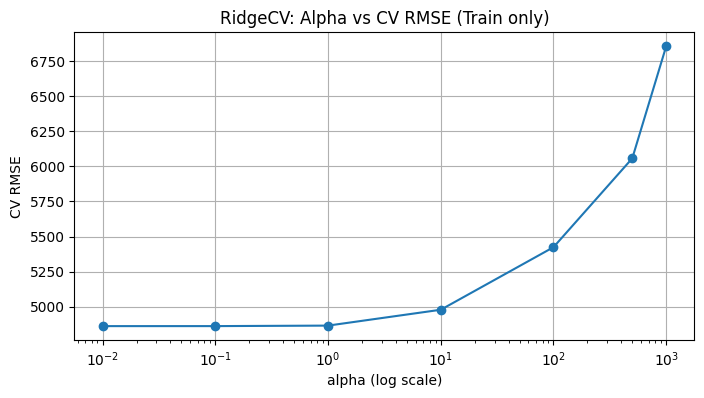

,alpha,cv_rmse
0,0.01,4861.164768
1,0.10,4861.287464
2,1.00,4864.818936
3,10.00,4977.909891
4,100.00,5423.951529
5,500.00,6057.544326
6,1000.00,6857.522000


In [76]:
# Summarize CV result per alpha (higher score is better because it's neg-RMSE)
cv_rmse = -ridge_cv.cv_values_.mean(axis=0) if hasattr(ridge_cv, "cv_values_") else None

if cv_rmse is None:
    from sklearn.model_selection import cross_val_score
    cv_rmse = []
    for a in alpha_list:
        model = Ridge(alpha=a)
        scores = cross_val_score(
            model, X_train_scaled, y_train,
            scoring="neg_root_mean_squared_error", cv=cv
        )
        cv_rmse.append(-scores.mean())
else:
    cv_rmse = list(cv_rmse)

cv_results_df = pd.DataFrame({
    "alpha": alpha_list,
    "cv_rmse": cv_rmse
})

plt.figure(figsize=(8, 4))
plt.plot(cv_results_df["alpha"], cv_results_df["cv_rmse"], marker="o")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("CV RMSE")
plt.title("RidgeCV: Alpha vs CV RMSE (Train only)")
plt.grid(True)
plt.show()

cv_results_df

## 6. Final model with the best alpha (from CV)
After selecting `best alpha` from train-CV, run final evaluation once on the test set.

In [77]:
# Retrain final model with the best alpha from CV
ridge_final = Ridge(alpha=best_alpha)
ridge_final.fit(X_train_scaled, y_train)

y_pred_final = ridge_final.predict(X_test_scaled)

mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print(f"Final model uses alpha (CV) = {best_alpha}")
print("=== Final Ridge Evaluation on Test Set ===")
print(f"MAE : {mae_final:.2f}")
print(f"RMSE: {rmse_final:.2f}")
print(f"R²  : {r2_final:.4f}")

Final model uses alpha (CV) = 0.01
=== Final Ridge Evaluation on Test Set ===
MAE : 2796.39
RMSE: 4705.71
R²  : 0.8407


## 7. Anti-Leakage Refactor: End-to-End Ridge Pipeline

Section ini mengganti workflow lama menjadi **pipeline anti-leakage** yang langsung mulai dari `insurance.csv` (raw data):

- Feature engineering dilakukan di dalam pipeline (`age_squared`, `smoker_bmi`)
- Encoding + scaling dilakukan di dalam `ColumnTransformer`
- Hyperparameter tuning dan evaluasi dilakukan hanya dengan data train + CV
- Data test tetap holdout final (tidak disentuh saat tuning)

Evaluasi lengkap yang ditambahkan:
1. Repeated cross-validation (mean + std)
2. Subgroup error (smoker / sex / region)
3. Learning curve (indikasi underfitting/overfitting)
4. Final holdout report (R2, RMSE, MAE)

In [78]:
# Anti-leakage setup: raw data -> split -> pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, RepeatedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


class FeatureBuilder(BaseEstimator, TransformerMixin):
    """Create interaction/polynomial features inside pipeline to avoid leakage."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_ = X.copy()
        X_["age_squared"] = X_["age"] ** 2
        X_["smoker_bmi"] = X_["bmi"] * (X_["smoker"] == "yes").astype(int)
        return X_


# Start from raw dataset (no pre-encoded file)
raw_df = pd.read_csv("insurance.csv").drop_duplicates().reset_index(drop=True)

X_raw = raw_df.drop(columns=["charges"])
y = raw_df["charges"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    random_state=42
)

numeric_features = ["age", "bmi", "children", "age_squared", "smoker_bmi"]
categorical_features = ["sex", "smoker", "region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ]
)

ridge_pipe = Pipeline(
    steps=[
        ("feature_builder", FeatureBuilder()),
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]
)

param_grid = {"model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
cv_strategy = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv_strategy,
    n_jobs=1,
    refit=True
)

grid.fit(X_train_raw, y_train)
best_model = grid.best_estimator_

# Holdout evaluation (untouched during tuning)
y_pred_train = best_model.predict(X_train_raw)
y_pred_test = best_model.predict(X_test_raw)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"Best alpha from CV: {grid.best_params_['model__alpha']}")
print("\n=== Holdout Performance ===")
print(f"R2   Train/Test: {train_r2:.4f} / {test_r2:.4f}")
print(f"RMSE Train/Test: {train_rmse:,.2f} / {test_rmse:,.2f}")
print(f"MAE  Train/Test: {train_mae:,.2f} / {test_mae:,.2f}")
print(f"Generalization gap (R2): {train_r2 - test_r2:.4f}")

Best alpha from CV: 0.1

=== Holdout Performance ===
R2   Train/Test: 0.8282 / 0.8857
RMSE Train/Test: 4,849.26 / 4,582.76
MAE  Train/Test: 2,943.00 / 2,884.67
Generalization gap (R2): -0.0575


In [79]:
# Cross-validation summary from GridSearchCV results
cv_results = pd.DataFrame(grid.cv_results_)[
    ["param_model__alpha", "mean_test_score", "std_test_score", "rank_test_score"]
].copy()

cv_results.rename(
    columns={
        "param_model__alpha": "alpha",
        "mean_test_score": "mean_neg_rmse",
        "std_test_score": "std_neg_rmse",
        "rank_test_score": "rank"
    },
    inplace=True
)

cv_results["cv_rmse_mean"] = -cv_results["mean_neg_rmse"]
cv_results["cv_rmse_std"] = cv_results["std_neg_rmse"]
cv_results = cv_results[["alpha", "cv_rmse_mean", "cv_rmse_std", "rank"]].sort_values("cv_rmse_mean")

print("=== CV Summary (RepeatedKFold, Train only) ===")
display(cv_results.reset_index(drop=True))

=== CV Summary (RepeatedKFold, Train only) ===


,alpha,cv_rmse_mean,cv_rmse_std,rank
0,0.100,4898.921888,349.861949,1
1,0.010,4899.095131,350.496030,2
2,0.001,4899.129557,350.563887,3
3,1.000,4908.780077,346.471994,4
4,10.000,5076.553956,346.285617,5
5,100.000,5332.342673,343.068214,6


In [80]:
# Subgroup error analysis on holdout set
holdout_eval = X_test_raw.copy()
holdout_eval["actual"] = y_test.values
holdout_eval["pred"] = y_pred_test
holdout_eval["abs_error"] = (holdout_eval["actual"] - holdout_eval["pred"]).abs()
holdout_eval["sq_error"] = (holdout_eval["actual"] - holdout_eval["pred"]) ** 2


def subgroup_metrics(df, group_col):
    rows = []
    for group_name, sub in df.groupby(group_col):
        r2 = r2_score(sub["actual"], sub["pred"])
        rmse = np.sqrt(sub["sq_error"].mean())
        mae = sub["abs_error"].mean()
        rows.append({
            "group_col": group_col,
            "group": group_name,
            "n": len(sub),
            "r2": r2,
            "rmse": rmse,
            "mae": mae,
        })
    return pd.DataFrame(rows).sort_values("rmse")

subgroup_report = pd.concat([
    subgroup_metrics(holdout_eval, "smoker"),
    subgroup_metrics(holdout_eval, "sex"),
    subgroup_metrics(holdout_eval, "region"),
], ignore_index=True)

print("=== Subgroup Error Report (Holdout) ===")
display(subgroup_report)

=== Subgroup Error Report (Holdout) ===


,group_col,group,n,r2,rmse,mae
0,smoker,no,208,0.516210,3919.063520,2351.277946
1,smoker,yes,60,0.711053,6368.901218,4733.767027
2,sex,male,125,0.897590,4515.450929,2923.720466
3,sex,female,143,0.872684,4640.801317,2850.536896
4,region,southeast,77,0.950996,3397.074208,2380.461840
5,region,southwest,60,0.904646,3901.455163,2591.908542
6,region,northeast,71,0.780000,5360.626723,3525.961910
7,region,northwest,60,0.850688,5456.357015,3065.641076


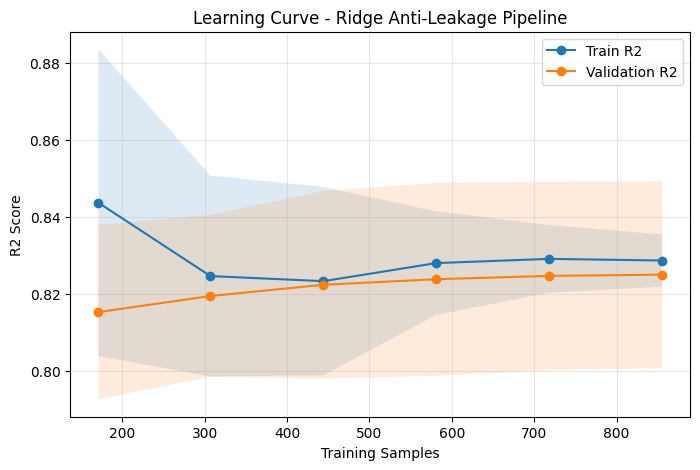

Last-point train R2: 0.8287
Last-point valid R2: 0.825
Gap: 0.0037


In [81]:
# Learning curve for bias/variance check
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(
    estimator=best_model,
    X=X_train_raw,
    y=y_train,
    train_sizes=np.linspace(0.2, 1.0, 6),
    cv=5,
    scoring="r2",
    n_jobs=1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
valid_mean = valid_scores.mean(axis=1)
valid_std = valid_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Train R2")
plt.plot(train_sizes, valid_mean, marker="o", label="Validation R2")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.15)
plt.title("Learning Curve - Ridge Anti-Leakage Pipeline")
plt.xlabel("Training Samples")
plt.ylabel("R2 Score")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("Last-point train R2:", round(float(train_mean[-1]), 4))
print("Last-point valid R2:", round(float(valid_mean[-1]), 4))
print("Gap:", round(float(train_mean[-1] - valid_mean[-1]), 4))

In [82]:
# Final holdout report (compact)
final_holdout_report = pd.DataFrame([
    {"metric": "R2", "train": train_r2, "test": test_r2, "gap_train_minus_test": train_r2 - test_r2},
    {"metric": "RMSE", "train": train_rmse, "test": test_rmse, "gap_train_minus_test": train_rmse - test_rmse},
    {"metric": "MAE", "train": train_mae, "test": test_mae, "gap_train_minus_test": train_mae - test_mae},
])

print("=== Final Holdout Report ===")
print(f"Best alpha (CV): {grid.best_params_['model__alpha']}")
display(final_holdout_report)

=== Final Holdout Report ===
Best alpha (CV): 0.1


,metric,train,test,gap_train_minus_test
0,R2,0.828248,0.885709,-0.057460
1,RMSE,4849.261090,4582.762320,266.498771
2,MAE,2943.004164,2884.671024,58.333140
